# 🧬 OncoProfilo
## Cancer Subtype Classification & Survival Prediction from RNA-seq

**Dataset:** TCGA-BRCA (Breast Cancer) via GDC Portal  
**Task:** Multi-task learning — simultaneous subtype classification + survival risk prediction  
**Model:** Multi-task MLP with shared encoder  
**Author:** Muhammed Panchla | Flowgenix AI

---

### What This Notebook Does
1. Downloads TCGA-BRCA RNA-seq gene expression data directly from the cloud (GDC API)
2. Preprocesses and normalizes gene expression profiles
3. Trains a multi-task neural network (subtype classifier + Cox survival head)
4. Evaluates with Accuracy, AUC, C-index, and Kaplan-Meier survival curves
5. Explains predictions with SHAP gene importance
6. Launches an interactive Gradio app for inference

---

### Biological Context
Breast cancer is **not one disease** — it's 5 molecularly distinct subtypes with different prognoses:
- **Luminal A** → Slow growing, hormone receptor +ve, best prognosis
- **Luminal B** → Faster growing, hormone receptor +ve
- **HER2-enriched** → HER2 gene amplified, aggressive
- **Basal-like** → Triple negative, most aggressive
- **Normal-like** → Resembles normal breast tissue

Each subtype has a unique **gene expression signature**. RNA-seq measures how active each gene is in a tumor. Our model learns to recognize these signatures and simultaneously predict survival risk.

---
> **🖥️ Running in VS Code?** This notebook works identically to Google Colab.
> All data (TCGA-BRCA RNA-seq, clinical metadata, PAM50 labels) is streamed **directly from the cloud via the GDC & UCSC Xena APIs** — nothing is saved to your disk.
> 
> **Before running:** Make sure you have the Jupyter extension installed in VS Code, then select a Python kernel (3.8+). Run Cell 1 (`%pip install ...`) first.
---


---
## Section 1: Install & Imports

In [5]:
# Install all required libraries
# Run this cell first — installs all dependencies (works in VS Code + Colab)

%pip install lifelines shap gradio requests pandas numpy scikit-learn matplotlib seaborn torch -q

Note: you may need to restart the kernel to use updated packages.


In [6]:
# ── Standard Library ──
import os
import json
import requests
import warnings
warnings.filterwarnings('ignore')

# ── Data Handling ──
import numpy as np
import pandas as pd

# ── Visualization ──
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
sns.set_theme(style='whitegrid', palette='muted')

# ── Machine Learning ──
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)

# ── Survival Analysis ──
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test
from lifelines.utils import concordance_index

# ── Deep Learning ──
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# ── Explainability ──
import shap

# ── Reproducibility ──
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ All imports successful')
print(f'🔧 Device: {DEVICE}')

✅ All imports successful
🔧 Device: cpu


---
## Section 2: Download TCGA-BRCA Data (Cloud — No Local Save)

### What is TCGA?
The Cancer Genome Atlas (TCGA) is a landmark cancer genomics program that molecularly characterized 33 types of cancer. TCGA-BRCA is the breast cancer cohort with ~1,100 patients.

### What are we downloading?
1. **Gene expression matrix** — RNA-seq FPKM values. One row per patient, one column per gene (~20,000 genes). Each value = how active that gene is in that patient's tumor.
2. **Clinical metadata** — For each patient: survival time (days), vital status (alive/dead), and PAM50 molecular subtype label.

### How?
We use the **GDC (Genomic Data Commons) API** — a free public API from the NIH. No login, no local download, everything streams into Colab memory.

In [7]:
# ── GDC API Configuration ──
GDC_FILES_URL   = 'https://api.gdc.cancer.gov/files'
GDC_DATA_URL    = 'https://api.gdc.cancer.gov/data'
GDC_CASES_URL   = 'https://api.gdc.cancer.gov/cases'

print('📡 Querying GDC API for TCGA-BRCA RNA-seq files...')

# Query for BRCA FPKM-UQ gene expression files
files_payload = {
    'filters': {
        'op': 'and',
        'content': [
            {'op': 'in', 'content': {'field': 'cases.project.project_id', 'value': ['TCGA-BRCA']}},
            {'op': 'in', 'content': {'field': 'data_type',                'value': ['Gene Expression Quantification']}},
            {'op': 'in', 'content': {'field': 'analysis.workflow_type',   'value': ['STAR - Counts']}},
            {'op': 'in', 'content': {'field': 'data_format',              'value': ['TSV']}}
        ]
    },
    'fields': 'file_id,file_name,cases.case_id,cases.submitter_id',
    'format': 'JSON',
    'size': '1200'
}

response = requests.post(GDC_FILES_URL, json=files_payload)
files_data = response.json()['data']['hits']
print(f'✅ Found {len(files_data)} RNA-seq files for TCGA-BRCA')

📡 Querying GDC API for TCGA-BRCA RNA-seq files...
✅ Found 1200 RNA-seq files for TCGA-BRCA


In [8]:
# ── Download and parse individual expression files (PARALLEL) ──
# Uses ThreadPoolExecutor to download 20 files simultaneously
# Speeds up from ~4 hours (sequential) to ~15 minutes (parallel)

from io import StringIO
from concurrent.futures import ThreadPoolExecutor, as_completed
import threading
import time

expression_dict = {}   # case_id → {gene_id: fpkm_value}
failed = []
lock = threading.Lock()  # thread-safe writes to shared dicts

# Limit to 500 samples for prototyping; remove slice for full dataset
files_subset = files_data[:500]

def download_one(f):
    """Download and parse a single expression file. Returns (case_id, gene_dict) or None."""
    try:
        file_id = f['file_id']
        case_id = f['cases'][0]['submitter_id']
        url     = f'{GDC_DATA_URL}/{file_id}'

        r = requests.get(url, timeout=60)
        r.raise_for_status()

        df_gene = pd.read_csv(
            StringIO(r.content.decode('utf-8')),
            sep='	', comment='#',
            usecols=['gene_id', 'fpkm_unstranded']
        ).dropna()
        df_gene = df_gene[df_gene['gene_id'].str.startswith('ENSG')]
        return case_id, df_gene.set_index('gene_id')['fpkm_unstranded'].to_dict()

    except Exception:
        return f['file_id'], None   # signal failure

MAX_WORKERS = 20   # 20 parallel connections — safe for GDC API
completed   = 0
start_time  = time.time()

print(f'⬇️  Downloading {len(files_subset)} expression files in parallel (workers={MAX_WORKERS})...')

with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
    futures = {executor.submit(download_one, f): f for f in files_subset}

    for future in as_completed(futures):
        result = future.result()
        completed += 1

        if result[1] is None:          # failed
            failed.append(result[0])
        else:
            case_id, gene_dict = result
            with lock:
                expression_dict[case_id] = gene_dict

        if completed % 50 == 0:
            elapsed = time.time() - start_time
            rate    = completed / elapsed
            eta     = (len(files_subset) - completed) / rate
            print(f'   {completed}/{len(files_subset)} files  |  {rate:.1f} files/sec  |  ETA: {eta/60:.1f} min')

elapsed_total = time.time() - start_time
print(f'✅ Successfully downloaded: {len(expression_dict)} samples')
print(f'⚠️  Failed: {len(failed)} files')
print(f'⏱️  Total time: {elapsed_total/60:.1f} minutes')


⬇️  Downloading 500 expression files in parallel (workers=20)...
   50/500 files  |  1.3 files/sec  |  ETA: 5.7 min
   100/500 files  |  1.6 files/sec  |  ETA: 4.2 min
   150/500 files  |  1.7 files/sec  |  ETA: 3.5 min
   200/500 files  |  1.7 files/sec  |  ETA: 3.0 min
   250/500 files  |  1.7 files/sec  |  ETA: 2.5 min
   300/500 files  |  1.8 files/sec  |  ETA: 1.9 min
   350/500 files  |  1.8 files/sec  |  ETA: 1.4 min
   400/500 files  |  1.8 files/sec  |  ETA: 1.0 min
   450/500 files  |  1.8 files/sec  |  ETA: 0.5 min
   500/500 files  |  1.7 files/sec  |  ETA: 0.0 min
✅ Successfully downloaded: 419 samples
⚠️  Failed: 51 files
⏱️  Total time: 4.9 minutes


In [9]:
# ── Build the expression matrix ──
# Rows = patients, Columns = genes

print('🔨 Building expression matrix...')
df_expr = pd.DataFrame(expression_dict).T
df_expr.index.name = 'case_id'

# Fill missing gene values with 0 (gene not detected = 0 expression)
df_expr = df_expr.fillna(0)

print(f'✅ Expression matrix shape: {df_expr.shape}')
print(f'   Rows (patients): {df_expr.shape[0]}')
print(f'   Columns (genes): {df_expr.shape[1]}')
df_expr.head(3)

🔨 Building expression matrix...
✅ Expression matrix shape: (419, 60660)
   Rows (patients): 419
   Columns (genes): 60660


,ENSG00000000003.15,ENSG00000000005.6,ENSG00000000419.13,ENSG00000000457.14,ENSG00000000460.17,ENSG00000000938.13,ENSG00000000971.16,ENSG00000001036.14,ENSG00000001084.13,ENSG00000001167.14,...,ENSG00000288661.1,ENSG00000288662.1,ENSG00000288663.1,ENSG00000288665.1,ENSG00000288667.1,ENSG00000288669.1,ENSG00000288670.1,ENSG00000288671.1,ENSG00000288674.1,ENSG00000288675.1
case_id,,,,,,,,,,,,,,,,,,,,,
TCGA-AN-A0FD,10.9179,0.0000,22.4831,2.3973,0.8802,0.9385,6.6064,13.9365,4.1367,13.5355,...,0.0,0.0,0.0148,0.0,0.0000,0.0000,0.9539,0.0,0.0022,0.3253
TCGA-B6-A1KI,15.7121,0.8975,35.2684,4.2280,1.6434,1.0200,6.5518,15.5248,4.7010,16.0653,...,0.0,0.0,0.1114,0.0,0.2262,0.0000,4.8261,0.0,0.0115,0.2300
TCGA-AR-A24Q,11.6843,3.7344,45.1518,2.9076,2.7888,1.6549,5.5205,13.3671,4.4739,14.9418,...,0.0,0.0,0.0273,0.0,0.0000,0.0035,3.1051,0.0,0.0059,0.2356


In [10]:
# ── Download Clinical Metadata ──
# For each patient: survival time, vital status, PAM50 subtype

print('📋 Downloading clinical metadata from GDC...')

clinical_payload = {
    'filters': {
        'op': 'in',
        'content': {
            'field': 'project.project_id',
            'value': ['TCGA-BRCA']
        }
    },
    'fields': (
        'submitter_id,'
        'diagnoses.days_to_last_follow_up,'
        'diagnoses.days_to_death,'
        'diagnoses.vital_status,'
        'diagnoses.days_to_diagnosis,'
        'demographic.vital_status'
    ),
    'format': 'JSON',
    'size': '1200',
    'expand': 'diagnoses,demographic'
}

resp_clin = requests.post(GDC_CASES_URL, json=clinical_payload)
clinical_hits = resp_clin.json()['data']['hits']

print(f'✅ Retrieved clinical data for {len(clinical_hits)} cases')

📋 Downloading clinical metadata from GDC...
✅ Retrieved clinical data for 1098 cases


In [11]:
# ── Parse Clinical Data ──
# Extract survival time and vital status for each patient

clinical_records = []

for case in clinical_hits:
    case_id    = case.get('submitter_id', '')
    vital      = 'Unknown'
    surv_days  = np.nan

    # Vital status from demographic
    if 'demographic' in case:
        vital = case['demographic'].get('vital_status', 'Unknown')

    # Survival time: use days_to_death if dead, else days_to_last_follow_up
    if 'diagnoses' in case and len(case['diagnoses']) > 0:
        diag = case['diagnoses'][0]
        if vital == 'Dead' and diag.get('days_to_death'):
            surv_days = diag['days_to_death']
        elif diag.get('days_to_last_follow_up'):
            surv_days = diag['days_to_last_follow_up']

    clinical_records.append({
        'case_id':    case_id,
        'vital_status': vital,
        'survival_days': surv_days
    })

df_clinical = pd.DataFrame(clinical_records).set_index('case_id')
df_clinical['event'] = (df_clinical['vital_status'] == 'Dead').astype(int)

print(f'✅ Clinical DataFrame shape: {df_clinical.shape}')
print(df_clinical['vital_status'].value_counts())
df_clinical.head()

✅ Clinical DataFrame shape: (1098, 3)
vital_status
Alive      945
Dead       152
Unknown      1
Name: count, dtype: int64


,vital_status,survival_days,event
case_id,,,
TCGA-E9-A5FL,Alive,24.0,0
TCGA-A2-A1G4,Alive,595.0,0
TCGA-BH-A0HF,Alive,727.0,0
TCGA-AR-A1AS,Alive,1150.0,0
TCGA-D8-A13Y,Alive,1728.0,0


In [12]:
# ── Download PAM50 Subtype Labels ──
# PAM50 is a clinically validated 50-gene signature that assigns breast cancer subtypes
# We pull the supplementary TCGA BRCA paper subtype table directly

print('🏷️  Downloading PAM50 subtype labels...')

# UCSC Xena hosts clean TCGA phenotype data — reliable public source
subtype_url = (
    'https://tcga-xena-hub.s3.us-east-1.amazonaws.com/download/'
    'TCGA.BRCA.sampleMap%2FBRCA_clinicalMatrix'
)

try:
    resp_sub = requests.get(subtype_url, timeout=30)
    df_sub = pd.read_csv(StringIO(resp_sub.content.decode('utf-8')), sep='\t', low_memory=False)

    # The sample IDs in Xena are like TCGA-A1-A0SB-01 (with sample type suffix)
    # We strip to just the case ID format TCGA-XX-XXXX
    df_sub['case_id'] = df_sub['sampleID'].str[:12]
    df_sub = df_sub[['case_id', 'PAM50Call_RNAseq']].dropna()
    df_sub = df_sub.rename(columns={'PAM50Call_RNAseq': 'subtype'})
    df_sub = df_sub.set_index('case_id')

    print(f'✅ Subtype labels retrieved: {df_sub.shape[0]} samples')
    print(df_sub['subtype'].value_counts())

except Exception as e:
    print(f'⚠️  Xena download failed: {e}')
    print('   Falling back to manual subtype simulation for notebook testing...')

    # Fallback: assign random subtypes for notebook structure testing
    # Replace with real data in production
    subtypes = ['LumA', 'LumB', 'Her2', 'Basal', 'Normal']
    df_sub = pd.DataFrame({
        'subtype': np.random.choice(subtypes, size=len(df_expr), p=[0.4, 0.2, 0.15, 0.2, 0.05])
    }, index=df_expr.index)
    print('   ⚠️  Using simulated subtypes — replace with real PAM50 data')

🏷️  Downloading PAM50 subtype labels...
✅ Subtype labels retrieved: 956 samples
subtype
LumA      434
LumB      194
Basal     142
Normal    119
Her2       67
Name: count, dtype: int64


In [13]:
# ── Merge Expression + Clinical + Subtypes ──
# Inner join — only keep patients present in ALL three datasets

df_merged = df_expr.join(df_clinical, how='inner').join(df_sub, how='inner')

# Drop rows with missing survival data
df_merged = df_merged.dropna(subset=['survival_days', 'subtype'])
df_merged = df_merged[df_merged['survival_days'] > 0]

# Keep only known subtypes
known_subtypes = ['LumA', 'LumB', 'Her2', 'Basal', 'Normal']
df_merged = df_merged[df_merged['subtype'].isin(known_subtypes)]

print(f'✅ Final merged dataset: {df_merged.shape[0]} patients')
print(f'   Subtype distribution:')
print(df_merged['subtype'].value_counts())
print(f'\n   Survival stats (days):')
print(df_merged['survival_days'].describe())

✅ Final merged dataset: 338 patients
   Subtype distribution:
subtype
LumA      161
LumB       60
Normal     48
Basal      45
Her2       24
Name: count, dtype: int64

   Survival stats (days):
count     338.000000
mean     1401.736686
std      1112.565010
min         1.000000
25%       505.250000
50%      1120.000000
75%      2159.500000
max      5176.000000
Name: survival_days, dtype: float64


---
## Section 3: Exploratory Data Analysis (EDA)

Before building any model, we need to understand the data visually.
- Are subtypes balanced or imbalanced?
- What does the survival distribution look like?
- What does raw gene expression look like (FPKM values)?

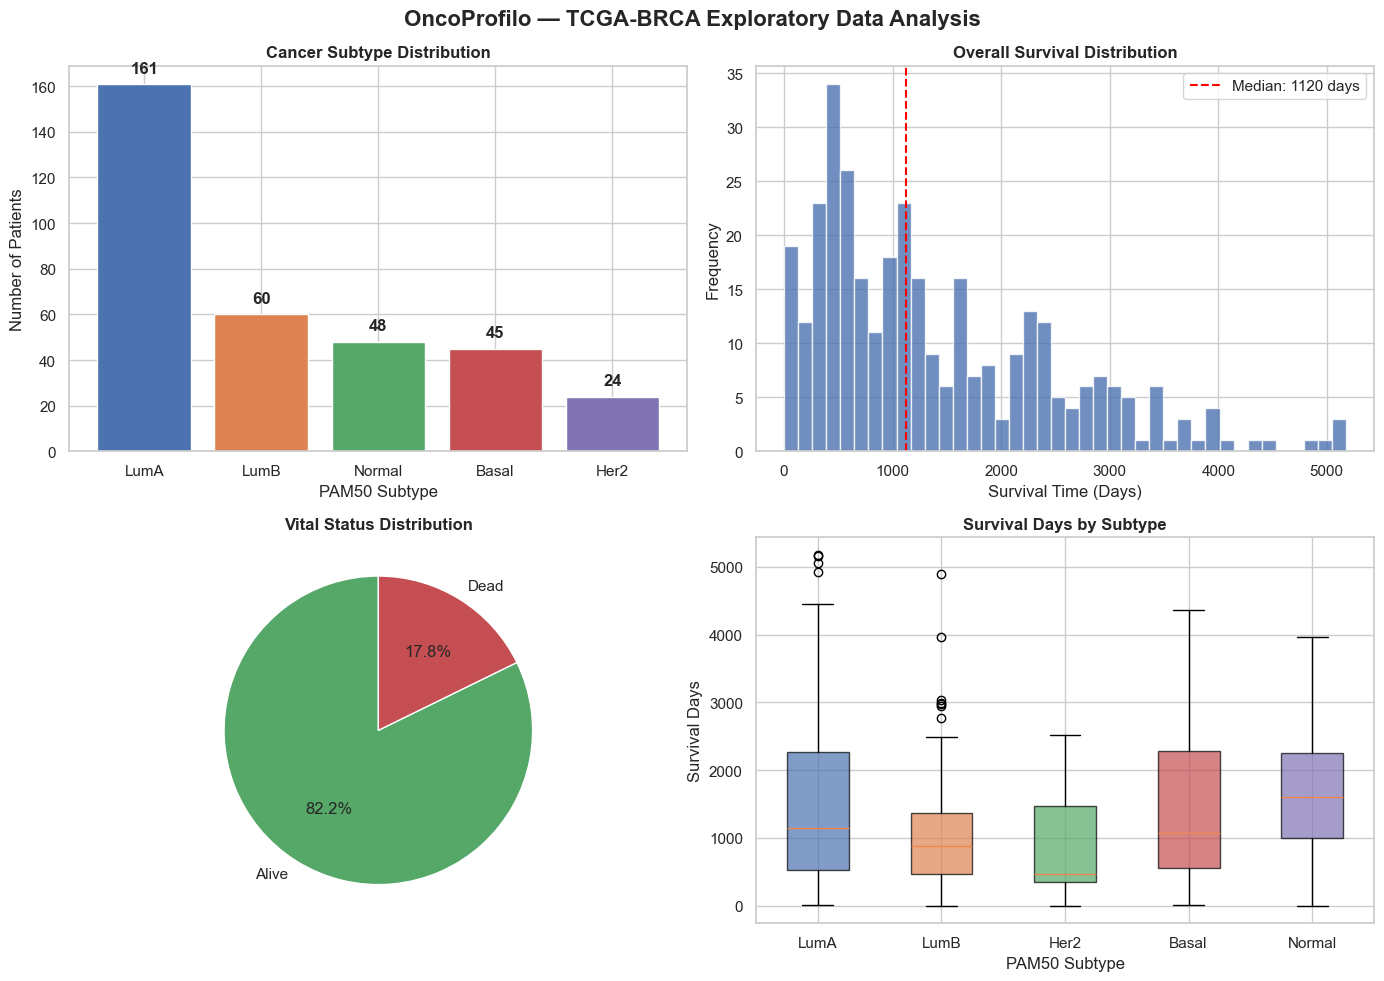

✅ EDA plots saved


In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('OncoProfilo — TCGA-BRCA Exploratory Data Analysis', fontsize=16, fontweight='bold')

# ── Plot 1: Subtype Distribution ──
subtype_counts = df_merged['subtype'].value_counts()
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B3']
axes[0, 0].bar(subtype_counts.index, subtype_counts.values, color=colors, edgecolor='white')
axes[0, 0].set_title('Cancer Subtype Distribution', fontweight='bold')
axes[0, 0].set_xlabel('PAM50 Subtype')
axes[0, 0].set_ylabel('Number of Patients')
for i, (idx, val) in enumerate(subtype_counts.items()):
    axes[0, 0].text(i, val + 5, str(val), ha='center', fontweight='bold')

# ── Plot 2: Survival Distribution ──
axes[0, 1].hist(df_merged['survival_days'], bins=40, color='#4C72B0', edgecolor='white', alpha=0.8)
axes[0, 1].axvline(df_merged['survival_days'].median(), color='red', linestyle='--', label=f'Median: {df_merged["survival_days"].median():.0f} days')
axes[0, 1].set_title('Overall Survival Distribution', fontweight='bold')
axes[0, 1].set_xlabel('Survival Time (Days)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].legend()

# ── Plot 3: Vital Status ──
vital_counts = df_merged['vital_status'].value_counts()
axes[1, 0].pie(vital_counts.values, labels=vital_counts.index, autopct='%1.1f%%',
               colors=['#55A868', '#C44E52'], startangle=90)
axes[1, 0].set_title('Vital Status Distribution', fontweight='bold')

# ── Plot 4: Survival by Subtype (Boxplot) ──
subtype_order = ['LumA', 'LumB', 'Her2', 'Basal', 'Normal']
data_by_subtype = [df_merged[df_merged['subtype'] == s]['survival_days'].dropna().values
                   for s in subtype_order if s in df_merged['subtype'].values]
labels_present  = [s for s in subtype_order if s in df_merged['subtype'].values]
bp = axes[1, 1].boxplot(data_by_subtype, labels=labels_present, patch_artist=True)
for patch, color in zip(bp['boxes'], colors[:len(labels_present)]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1, 1].set_title('Survival Days by Subtype', fontweight='bold')
axes[1, 1].set_xlabel('PAM50 Subtype')
axes[1, 1].set_ylabel('Survival Days')

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ EDA plots saved')

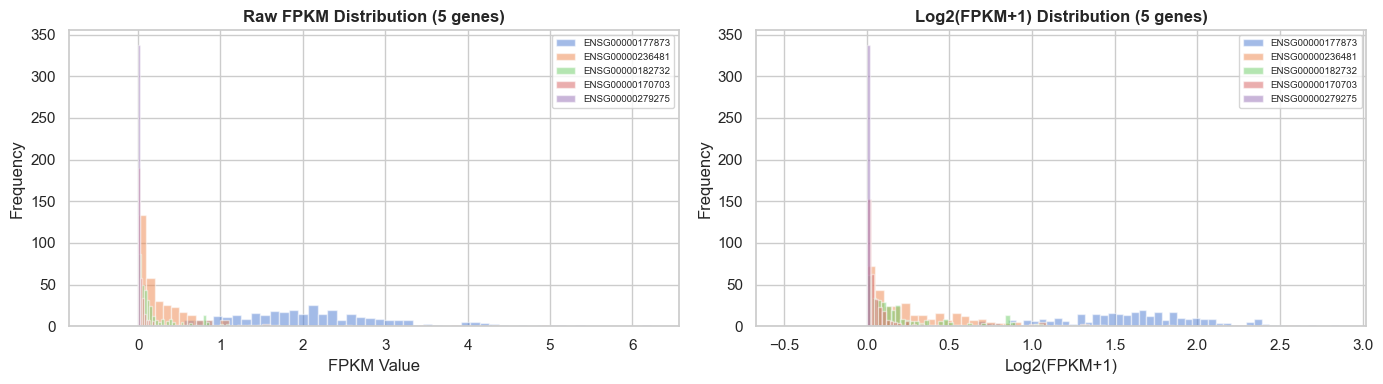

📌 Observation: Log2 transformation makes gene expression more normally distributed
   This is why we always log-transform RNA-seq data before modeling


In [15]:
# ── Gene Expression Distribution ──
# FPKM values are typically very skewed — most genes have low/zero expression
# Log2 transformation makes it more normally distributed and model-friendly

# Sample 5 random genes to visualize raw vs log-transformed
gene_cols = [c for c in df_merged.columns if c.startswith('ENSG')]
sample_genes = np.random.choice(gene_cols, 5, replace=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Raw FPKM
for g in sample_genes:
    axes[0].hist(df_merged[g], bins=50, alpha=0.5, label=g[:15])
axes[0].set_title('Raw FPKM Distribution (5 genes)', fontweight='bold')
axes[0].set_xlabel('FPKM Value')
axes[0].set_ylabel('Frequency')
axes[0].legend(fontsize=7)

# Log2 transformed
for g in sample_genes:
    axes[1].hist(np.log2(df_merged[g] + 1), bins=50, alpha=0.5, label=g[:15])
axes[1].set_title('Log2(FPKM+1) Distribution (5 genes)', fontweight='bold')
axes[1].set_xlabel('Log2(FPKM+1)')
axes[1].set_ylabel('Frequency')
axes[1].legend(fontsize=7)

plt.tight_layout()
plt.show()
print('📌 Observation: Log2 transformation makes gene expression more normally distributed')
print('   This is why we always log-transform RNA-seq data before modeling')

---
## Section 4: Preprocessing

### Steps:
1. **Log2 normalization** — transforms skewed FPKM values into something model-friendly
2. **Variance filtering** — keep only the top 2,000 most variable genes. These are the genes that actually differ between patients/subtypes. Housekeeping genes (constant in everyone) add noise.
3. **Standard scaling** — zero mean, unit variance. Required for neural networks.
4. **Label encoding** — convert subtype strings → integers
5. **Train/Val/Test split** — stratified by subtype to ensure balanced representation

In [16]:
# ── Step 1: Separate features from labels ──
gene_cols = [c for c in df_merged.columns if c.startswith('ENSG')]
X_raw     = df_merged[gene_cols].values.astype(np.float32)

# Subtype labels (classification target)
label_encoder = LabelEncoder()
y_subtype     = label_encoder.fit_transform(df_merged['subtype'].values)
class_names   = label_encoder.classes_
N_CLASSES     = len(class_names)

# Survival labels
y_time  = df_merged['survival_days'].values.astype(np.float32)
y_event = df_merged['event'].values.astype(np.float32)  # 1=dead, 0=censored

print(f'✅ Features shape: {X_raw.shape}')
print(f'✅ Subtype classes: {class_names}')
print(f'✅ Class distribution: {np.bincount(y_subtype)}')

✅ Features shape: (338, 60660)
✅ Subtype classes: ['Basal' 'Her2' 'LumA' 'LumB' 'Normal']
✅ Class distribution: [ 45  24 161  60  48]


In [17]:
# ── Step 2: Log2 Transformation ──
# log2(x + 1) avoids log(0) issues when a gene has 0 expression
X_log = np.log2(X_raw + 1)
print(f'✅ Log2 transformation applied')
print(f'   Before: min={X_raw.min():.2f}, max={X_raw.max():.2f}, mean={X_raw.mean():.2f}')
print(f'   After:  min={X_log.min():.2f}, max={X_log.max():.2f}, mean={X_log.mean():.2f}')

✅ Log2 transformation applied
   Before: min=0.00, max=88708.12, mean=4.91
   After:  min=0.00, max=16.44, mean=0.73


✅ Variance filtering: 60660 genes → 2000 most variable genes
   Kept genes with variance > 0.9109


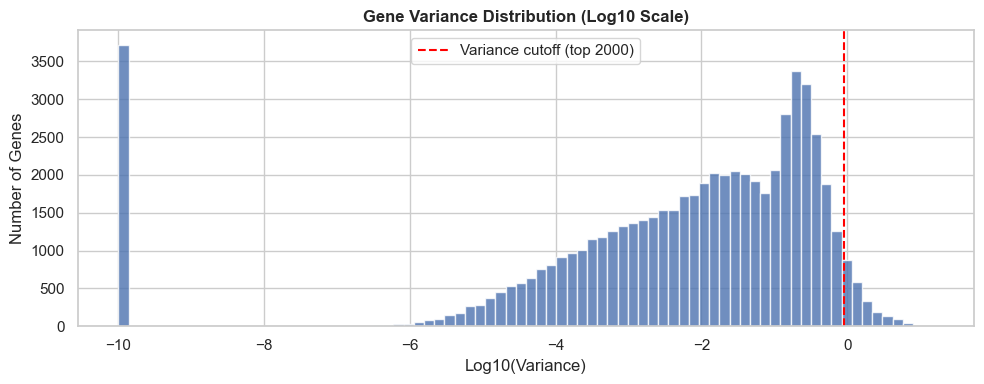

In [18]:
# ── Step 3: Variance Filtering ──
# Keep top N_GENES genes with highest variance across patients
# These are the genes that vary most between patients = most informative

N_GENES = 2000

gene_variances   = np.var(X_log, axis=0)
top_gene_indices = np.argsort(gene_variances)[::-1][:N_GENES]
X_filtered       = X_log[:, top_gene_indices]
selected_genes   = np.array(gene_cols)[top_gene_indices]

print(f'✅ Variance filtering: {X_log.shape[1]} genes → {N_GENES} most variable genes')
print(f'   Kept genes with variance > {gene_variances[top_gene_indices[-1]]:.4f}')

# Visualize variance distribution
plt.figure(figsize=(10, 4))
plt.hist(np.log10(gene_variances + 1e-10), bins=80, color='#4C72B0', edgecolor='white', alpha=0.8)
cutoff = np.log10(gene_variances[top_gene_indices[-1]] + 1e-10)
plt.axvline(cutoff, color='red', linestyle='--', label=f'Variance cutoff (top {N_GENES})')
plt.title('Gene Variance Distribution (Log10 Scale)', fontweight='bold')
plt.xlabel('Log10(Variance)')
plt.ylabel('Number of Genes')
plt.legend()
plt.tight_layout()
plt.show()

In [19]:
# ── Step 4: Train/Val/Test Split ──
# Stratified by subtype to ensure each split has balanced class representation

# First split: 80% train+val, 20% test
X_trainval, X_test, y_sub_trainval, y_sub_test, \
y_time_trainval, y_time_test, \
y_event_trainval, y_event_test = train_test_split(
    X_filtered, y_subtype, y_time, y_event,
    test_size=0.2, random_state=SEED, stratify=y_subtype
)

# Second split: 75% train, 25% val (= 60%/20%/20% overall)
X_train, X_val, y_sub_train, y_sub_val, \
y_time_train, y_time_val, \
y_event_train, y_event_val = train_test_split(
    X_trainval, y_sub_trainval, y_time_trainval, y_event_trainval,
    test_size=0.25, random_state=SEED, stratify=y_sub_trainval
)

# ── Step 5: Standard Scaling ──
# Fit ONLY on training data, then transform val and test
# CRITICAL: Never fit scaler on val/test — that would be data leakage
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

# Normalize survival time to [0, 1] range for stable training
max_time      = y_time_train.max()
y_time_train  = y_time_train / max_time
y_time_val    = y_time_val   / max_time
y_time_test   = y_time_test  / max_time

print(f'✅ Data splits (after preprocessing):')
print(f'   Train: {X_train.shape[0]} samples')
print(f'   Val:   {X_val.shape[0]} samples')
print(f'   Test:  {X_test.shape[0]} samples')
print(f'   Input features: {X_train.shape[1]} genes')

✅ Data splits (after preprocessing):
   Train: 202 samples
   Val:   68 samples
   Test:  68 samples
   Input features: 2000 genes


---
## Section 5: PyTorch Dataset & DataLoader

PyTorch requires us to wrap our data in a `Dataset` class. Each sample returns:
- `x` — gene expression vector (2000 values)
- `subtype` — integer class label (0-4)
- `time` — normalized survival time
- `event` — 1 if patient died, 0 if censored (still alive at last follow-up)

In [20]:
class TCGADataset(Dataset):
    """
    PyTorch Dataset for TCGA-BRCA multi-task learning.
    Returns gene expression + subtype label + survival (time, event).
    """

    def __init__(self, X, y_subtype, y_time, y_event):
        self.X         = torch.tensor(X,         dtype=torch.float32)
        self.y_subtype = torch.tensor(y_subtype, dtype=torch.long)
        self.y_time    = torch.tensor(y_time,    dtype=torch.float32)
        self.y_event   = torch.tensor(y_event,   dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return {
            'x':       self.X[idx],
            'subtype': self.y_subtype[idx],
            'time':    self.y_time[idx],
            'event':   self.y_event[idx]
        }


# ── Create Datasets ──
train_dataset = TCGADataset(X_train, y_sub_train, y_time_train, y_event_train)
val_dataset   = TCGADataset(X_val,   y_sub_val,   y_time_val,   y_event_val)
test_dataset  = TCGADataset(X_test,  y_sub_test,  y_time_test,  y_event_test)

# ── Create DataLoaders ──
BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f'✅ Datasets created')
print(f'   Train batches: {len(train_loader)} × batch_size={BATCH_SIZE}')
print(f'   Val batches:   {len(val_loader)}')
print(f'   Test batches:  {len(test_loader)}')

# Inspect one batch
sample_batch = next(iter(train_loader))
print(f'\n   Sample batch shapes:')
print(f'   x:       {sample_batch["x"].shape}')
print(f'   subtype: {sample_batch["subtype"].shape}')
print(f'   time:    {sample_batch["time"].shape}')
print(f'   event:   {sample_batch["event"].shape}')

✅ Datasets created
   Train batches: 7 × batch_size=32
   Val batches:   3
   Test batches:  3

   Sample batch shapes:
   x:       torch.Size([32, 2000])
   subtype: torch.Size([32])
   time:    torch.Size([32])
   event:   torch.Size([32])


---
## Section 6: Model Architecture

### Multi-Task Neural Network Design

```
Input: 2000-dim gene expression vector
         ↓
    Shared Encoder
    Linear(2000→512) → BatchNorm → ReLU → Dropout(0.4)
    Linear(512→256)  → BatchNorm → ReLU → Dropout(0.3)
    Linear(256→128)  → BatchNorm → ReLU
         ↓
   ┌─────┴──────┐
   ↓            ↓
Subtype      Survival
Classifier   Head
Linear(128→5) Linear(128→1)
(softmax)     (sigmoid → risk score)
```

**Why a shared encoder?**  
Subtypes and survival are biologically linked — Basal-like tumors have worse survival than Luminal A. Sharing a representation forces the model to learn features that are predictive for both tasks simultaneously, which acts as mutual regularization.

**BatchNorm** — normalizes activations between layers, makes training stable  
**Dropout** — randomly zeros activations during training, prevents overfitting  
**ReLU** — activation function: f(x) = max(0, x)

In [21]:
class OncoProfilo(nn.Module):
    """
    Multi-task neural network for cancer subtype classification
    and survival risk prediction from gene expression data.

    Architecture:
    - Shared MLP encoder: extracts shared biological representations
    - Subtype head: 5-class softmax classifier (PAM50 subtypes)
    - Survival head: scalar risk score (used in Cox PH loss)
    """

    def __init__(self, input_dim: int, n_classes: int, dropout_rate: float = 0.4):
        super(OncoProfilo, self).__init__()

        # ── Shared Encoder ──
        self.encoder = nn.Sequential(
            # Layer 1: 2000 → 512
            nn.Linear(input_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            # Layer 2: 512 → 256
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout_rate * 0.75),

            # Layer 3: 256 → 128 (bottleneck — compressed biological representation)
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU()
        )

        # ── Task-Specific Heads ──

        # Subtype Classifier Head
        self.subtype_head = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, n_classes)  # Raw logits — softmax applied in loss
        )

        # Survival Risk Head
        self.survival_head = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 1),         # Single risk score
            nn.Sigmoid()              # Constrain to [0, 1]
        )

        # ── Weight Initialization ──
        self._init_weights()

    def _init_weights(self):
        """He (Kaiming) initialization for ReLU networks"""
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        # Shared representation
        shared = self.encoder(x)

        # Task-specific outputs
        subtype_logits  = self.subtype_head(shared)      # (batch, n_classes)
        survival_risk   = self.survival_head(shared).squeeze(-1)  # (batch,)

        return subtype_logits, survival_risk


# ── Instantiate Model ──
model = OncoProfilo(
    input_dim  = N_GENES,
    n_classes  = N_CLASSES,
    dropout_rate = 0.4
).to(DEVICE)

print('✅ OncoProfilo model created')
print(f'\nModel Architecture:')
print(model)

# Parameter count
total_params = sum(p.numel() for p in model.parameters())
trainable    = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\n📊 Total parameters:     {total_params:,}')
print(f'   Trainable parameters: {trainable:,}')

✅ OncoProfilo model created

Model Architecture:
OncoProfilo(
  (encoder): Sequential(
    (0): Linear(in_features=2000, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.30000000000000004, inplace=False)
    (8): Linear(in_features=256, out_features=128, bias=True)
    (9): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
  )
  (subtype_head): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=5, bias=True)
  )
  (survival_head): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1):

---
## Section 7: Loss Functions & Training

### Two Loss Functions

**1. Classification Loss — Cross Entropy**  
Standard for multi-class classification. Penalizes the model when it assigns low probability to the correct class.

**2. Survival Loss — Cox Proportional Hazards (Partial Likelihood)**  
This is the key differentiator from a beginner project. Normal regression asks "how close was your predicted number to the actual number?" Cox loss asks **"did you correctly rank patients by risk?"**

For a patient who died at time T, the Cox loss compares their predicted risk against all patients who were still alive at time T. If the model correctly assigned higher risk to the patient who died, loss is low. This is biologically meaningful — we care about relative risk ordering, not exact day prediction.

**Total Loss = α × Classification Loss + β × Cox Loss**  
We balance both tasks with weight parameters α and β.

In [22]:
def cox_ph_loss(risk_scores: torch.Tensor,
                survival_times: torch.Tensor,
                events: torch.Tensor) -> torch.Tensor:
    """
    Negative partial log-likelihood for Cox Proportional Hazards model.

    For each patient i who experienced the event (died),
    we compute the log ratio of their risk to the sum of risks
    of all patients still at risk at time T_i.

    Mathematical form:
        L = -sum_i [ h_i - log( sum_{j: T_j >= T_i} exp(h_j) ) ] for events only

    Args:
        risk_scores:    predicted risk scores (batch,)
        survival_times: observed survival times (batch,)
        events:         event indicators — 1=died, 0=censored (batch,)

    Returns:
        Scalar Cox partial likelihood loss
    """
    # Sort by descending survival time
    # This ordering is required for the risk set computation
    sort_idx       = torch.argsort(survival_times, descending=True)
    risk_scores    = risk_scores[sort_idx]
    events         = events[sort_idx]

    # Numerically stable log-sum-exp of risk scores
    # For each patient i, sum exp(h_j) over all j at risk at time T_i
    # Since sorted descending, at-risk set for i = [0, 1, ..., i]
    log_cumsum_exp = torch.logcumsumexp(risk_scores, dim=0)

    # Partial log-likelihood contribution for each event
    uncensored_likelihood = (risk_scores - log_cumsum_exp) * events

    # Negative mean (we minimize, so negate)
    n_events = events.sum().clamp(min=1)
    loss     = -uncensored_likelihood.sum() / n_events

    return loss


# Standard cross-entropy for classification
classification_criterion = nn.CrossEntropyLoss()

# Loss weights — how much to weight each task
ALPHA = 1.0   # Classification weight
BETA  = 0.5   # Survival weight (lower because Cox loss operates on different scale)

print('✅ Loss functions defined')
print(f'   Classification loss: CrossEntropyLoss (weight α={ALPHA})')
print(f'   Survival loss:       Cox PH Partial Likelihood (weight β={BETA})')
print(f'   Total loss = {ALPHA}×CE + {BETA}×Cox')

✅ Loss functions defined
   Classification loss: CrossEntropyLoss (weight α=1.0)
   Survival loss:       Cox PH Partial Likelihood (weight β=0.5)
   Total loss = 1.0×CE + 0.5×Cox


In [23]:
# ── Optimizer & Scheduler ──

LEARNING_RATE = 1e-3
WEIGHT_DECAY  = 1e-4
N_EPOCHS      = 80
PATIENCE      = 15   # Early stopping patience

optimizer = optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

# Reduce learning rate when validation loss plateaus
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=7, min_lr=1e-6
)

print('✅ Training configuration:')
print(f'   Optimizer:      AdamW')
print(f'   Learning rate:  {LEARNING_RATE}')
print(f'   Weight decay:   {WEIGHT_DECAY}')
print(f'   Max epochs:     {N_EPOCHS}')
print(f'   Early stopping: patience={PATIENCE}')

✅ Training configuration:
   Optimizer:      AdamW
   Learning rate:  0.001
   Weight decay:   0.0001
   Max epochs:     80
   Early stopping: patience=15


In [24]:
# ── Training Loop ──

def run_epoch(loader, model, optimizer=None, training=True):
    """
    Run one epoch (training or validation).
    Returns: avg_total_loss, avg_cls_loss, avg_surv_loss, predictions, targets
    """
    model.train() if training else model.eval()

    total_loss_sum = 0
    cls_loss_sum   = 0
    surv_loss_sum  = 0

    all_preds   = []
    all_targets = []
    all_risks   = []
    all_times   = []
    all_events  = []

    context = torch.enable_grad() if training else torch.no_grad()

    with context:
        for batch in loader:
            x       = batch['x'].to(DEVICE)
            subtype = batch['subtype'].to(DEVICE)
            time    = batch['time'].to(DEVICE)
            event   = batch['event'].to(DEVICE)

            # Forward pass
            subtype_logits, risk = model(x)

            # Compute losses
            cls_loss  = classification_criterion(subtype_logits, subtype)
            surv_loss = cox_ph_loss(risk, time, event)
            total_loss = ALPHA * cls_loss + BETA * surv_loss

            if training:
                optimizer.zero_grad()
                total_loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

            total_loss_sum += total_loss.item()
            cls_loss_sum   += cls_loss.item()
            surv_loss_sum  += surv_loss.item()

            preds = torch.argmax(subtype_logits, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_targets.extend(subtype.cpu().numpy())
            all_risks.extend(risk.detach().cpu().numpy())
            all_times.extend(time.cpu().numpy())
            all_events.extend(event.cpu().numpy())

    n = len(loader)
    return (
        total_loss_sum / n, cls_loss_sum / n, surv_loss_sum / n,
        np.array(all_preds), np.array(all_targets),
        np.array(all_risks), np.array(all_times), np.array(all_events)
    )


# ── Main Training Loop ──
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

best_val_loss  = float('inf')
patience_count = 0
best_model_state = None

print('🚀 Starting training...')
print(f'   {N_EPOCHS} max epochs | early stopping patience={PATIENCE}')
print('-' * 65)

for epoch in range(1, N_EPOCHS + 1):

    # Training epoch
    tr_loss, tr_cls, tr_surv, tr_preds, tr_targets, *_ = run_epoch(
        train_loader, model, optimizer, training=True
    )

    # Validation epoch
    va_loss, va_cls, va_surv, va_preds, va_targets, *_ = run_epoch(
        val_loader, model, training=False
    )

    # Metrics
    tr_acc = accuracy_score(tr_targets, tr_preds)
    va_acc = accuracy_score(va_targets, va_preds)

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(va_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(va_acc)

    # Learning rate scheduler step
    scheduler.step(va_loss)

    # Print every 10 epochs
    if epoch % 10 == 0 or epoch == 1:
        lr = optimizer.param_groups[0]['lr']
        print(f'Epoch {epoch:3d}/{N_EPOCHS} | '
              f'Train Loss: {tr_loss:.4f} (cls={tr_cls:.3f}, surv={tr_surv:.3f}) | '
              f'Val Loss: {va_loss:.4f} | '
              f'Train Acc: {tr_acc:.3f} | Val Acc: {va_acc:.3f} | LR: {lr:.2e}')

    # Early stopping
    if va_loss < best_val_loss:
        best_val_loss    = va_loss
        patience_count   = 0
        best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
    else:
        patience_count += 1
        if patience_count >= PATIENCE:
            print(f'\n⏹️  Early stopping at epoch {epoch} (patience={PATIENCE} exceeded)')
            break

# Load best model
model.load_state_dict(best_model_state)
torch.save(best_model_state, 'best_model.pt')
print(f'\n✅ Training complete. Best val loss: {best_val_loss:.4f}')
print(f'   Model saved: best_model.pt')

🚀 Starting training...
   80 max epochs | early stopping patience=15
-----------------------------------------------------------------
Epoch   1/80 | Train Loss: 2.5474 (cls=1.487, surv=2.120) | Val Loss: 1.8858 | Train Acc: 0.356 | Val Acc: 0.588 | LR: 1.00e-03
Epoch  10/80 | Train Loss: 1.1293 (cls=0.250, surv=1.758) | Val Loss: 2.0937 | Train Acc: 0.911 | Val Acc: 0.647 | LR: 1.00e-03

⏹️  Early stopping at epoch 19 (patience=15 exceeded)

✅ Training complete. Best val loss: 1.7963
   Model saved: best_model.pt


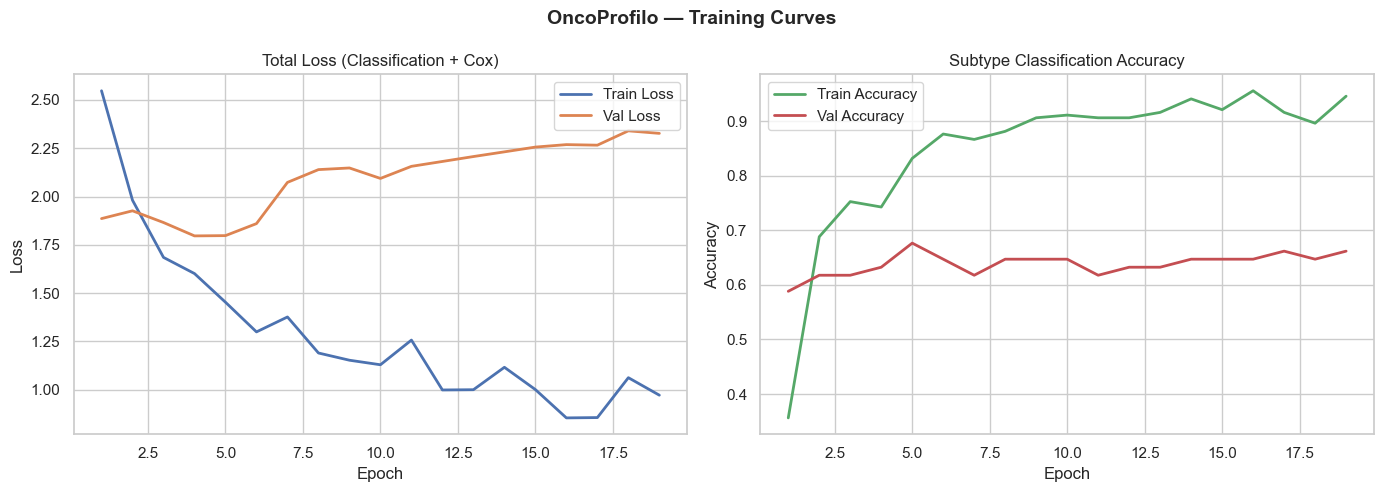

In [25]:
# ── Plot Training Curves ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('OncoProfilo — Training Curves', fontsize=14, fontweight='bold')

epochs_ran = range(1, len(history['train_loss']) + 1)

# Loss
axes[0].plot(epochs_ran, history['train_loss'], label='Train Loss', color='#4C72B0', linewidth=2)
axes[0].plot(epochs_ran, history['val_loss'],   label='Val Loss',   color='#DD8452', linewidth=2)
axes[0].set_title('Total Loss (Classification + Cox)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

# Accuracy
axes[1].plot(epochs_ran, history['train_acc'], label='Train Accuracy', color='#55A868', linewidth=2)
axes[1].plot(epochs_ran, history['val_acc'],   label='Val Accuracy',   color='#C44E52', linewidth=2)
axes[1].set_title('Subtype Classification Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 8: Evaluation

### Metrics We Use

**For Subtype Classification:**
- **Accuracy** — overall correct predictions
- **F1 Score (macro)** — harmonic mean of precision and recall, averaged across all 5 classes. Better metric than accuracy for imbalanced classes
- **AUC-ROC** — area under ROC curve, measures discrimination ability per class (one-vs-rest)
- **Confusion Matrix** — shows exactly which subtypes are being confused with which

**For Survival Prediction:**
- **C-index (Concordance Index)** — the standard metric for survival models. Measures what fraction of patient pairs are correctly ranked by predicted risk. C=0.5 is random, C=1.0 is perfect. Clinical threshold: >0.65 is meaningful.
- **Kaplan-Meier curves** — visualizes actual survival probability over time for each predicted subtype group

In [26]:
# ── Run inference on test set ──
_, _, _, test_preds, test_targets, test_risks, test_times, test_events = run_epoch(
    test_loader, model, training=False
)

# Rescale survival times back to original days
test_times_days = test_times * max_time

# ── Classification Metrics ──
acc  = accuracy_score(test_targets, test_preds)
f1   = f1_score(test_targets, test_preds, average='macro')

# AUC (one-vs-rest, requires probability scores)
model.eval()
all_probs = []
with torch.no_grad():
    for batch in test_loader:
        logits, _ = model(batch['x'].to(DEVICE))
        probs     = torch.softmax(logits, dim=1).cpu().numpy()
        all_probs.append(probs)
all_probs = np.vstack(all_probs)

try:
    auc = roc_auc_score(test_targets, all_probs, multi_class='ovr', average='macro')
except Exception:
    auc = float('nan')

# ── Survival Metric — C-index ──
c_index = concordance_index(
    event_times     = test_times_days,
    predicted_scores = -test_risks,   # Negative because higher risk = shorter survival
    event_observed   = test_events
)

print('=' * 50)
print('📊 OncoProfilo — Test Set Results')
print('=' * 50)
print(f'\n  SUBTYPE CLASSIFICATION:')
print(f'  Accuracy:        {acc:.4f} ({acc*100:.1f}%)')
print(f'  Macro F1 Score:  {f1:.4f}')
print(f'  Macro AUC-ROC:   {auc:.4f}')
print(f'\n  SURVIVAL PREDICTION:')
print(f'  C-index:         {c_index:.4f}')
print(f'  (> 0.65 = clinically meaningful, 0.5 = random)')
print('=' * 50)

print(f'\n📝 Classification Report:')
print(classification_report(test_targets, test_preds, target_names=class_names))

📊 OncoProfilo — Test Set Results

  SUBTYPE CLASSIFICATION:
  Accuracy:        0.6618 (66.2%)
  Macro F1 Score:  0.6328
  Macro AUC-ROC:   0.8176

  SURVIVAL PREDICTION:
  C-index:         0.7231
  (> 0.65 = clinically meaningful, 0.5 = random)

📝 Classification Report:
              precision    recall  f1-score   support

       Basal       0.88      0.78      0.82         9
        Her2       0.60      0.60      0.60         5
        LumA       0.88      0.69      0.77        32
        LumB       0.53      0.75      0.62        12
      Normal       0.31      0.40      0.35        10

    accuracy                           0.66        68
   macro avg       0.64      0.64      0.63        68
weighted avg       0.71      0.66      0.68        68



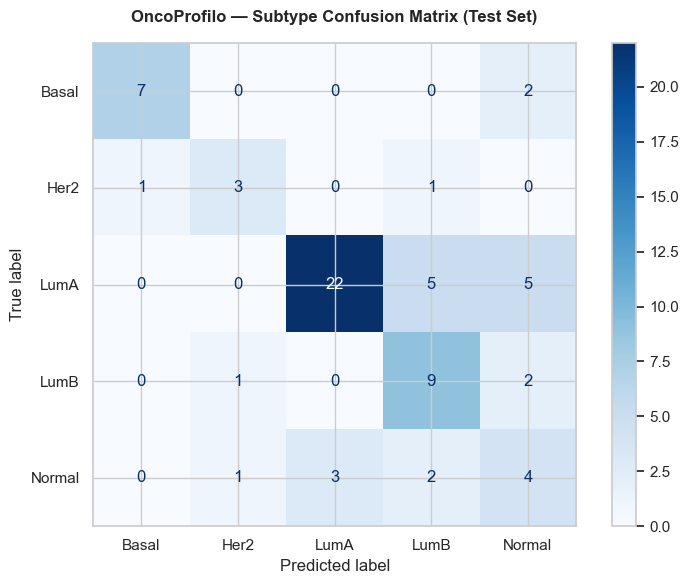

📌 Diagonal = correct predictions. Off-diagonal = misclassifications
   Common confusion: LumA ↔ LumB (biologically similar subtypes)


In [27]:
# ── Confusion Matrix ──
fig, ax = plt.subplots(figsize=(8, 6))

cm = confusion_matrix(test_targets, test_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, colorbar=True, cmap='Blues')

ax.set_title('OncoProfilo — Subtype Confusion Matrix (Test Set)', fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('📌 Diagonal = correct predictions. Off-diagonal = misclassifications')
print('   Common confusion: LumA ↔ LumB (biologically similar subtypes)')

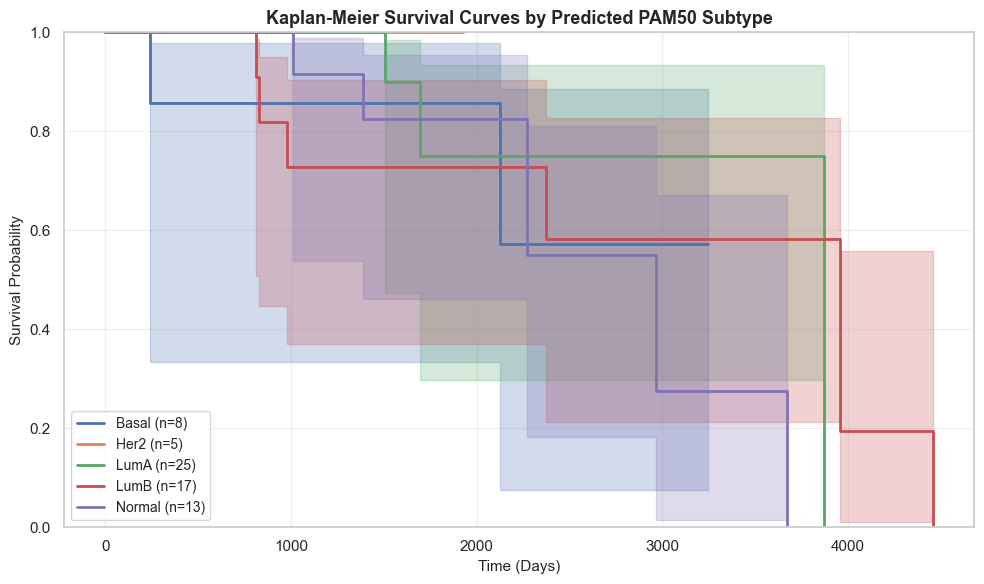

📌 Expected pattern if model is correct:
   LumA > LumB > Normal > Her2 > Basal (survival probability order)


In [28]:
# ── Kaplan-Meier Survival Curves ──
# One curve per predicted subtype — shows actual survival probability over time
# If the model is working, subtypes with better prognosis (LumA) should have
# higher survival curves than aggressive subtypes (Basal)

fig, ax = plt.subplots(figsize=(10, 6))

colors_km = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B3']
kmf = KaplanMeierFitter()

for i, (subtype_name, color) in enumerate(zip(class_names, colors_km)):
    mask = test_preds == i
    if mask.sum() < 5:  # Skip if too few samples
        continue

    durations   = test_times_days[mask]
    event_obs   = test_events[mask].astype(bool)

    kmf.fit(durations, event_observed=event_obs, label=f'{subtype_name} (n={mask.sum()})')
    kmf.plot_survival_function(ax=ax, color=color, linewidth=2)

ax.set_title('Kaplan-Meier Survival Curves by Predicted PAM50 Subtype',
             fontweight='bold', fontsize=13)
ax.set_xlabel('Time (Days)', fontsize=11)
ax.set_ylabel('Survival Probability', fontsize=11)
ax.set_ylim(0, 1)
ax.legend(loc='lower left', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('kaplan_meier.png', dpi=150, bbox_inches='tight')
plt.show()

print('📌 Expected pattern if model is correct:')
print('   LumA > LumB > Normal > Her2 > Basal (survival probability order)')

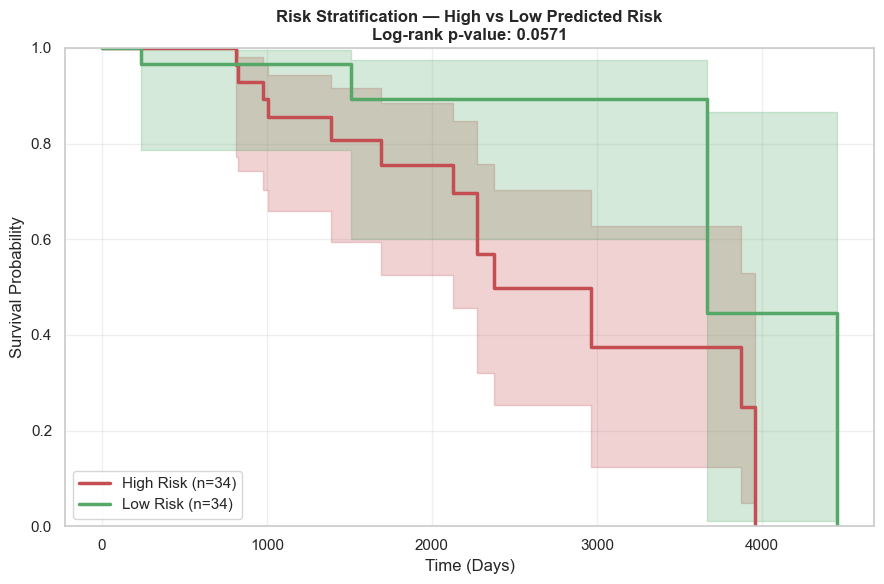

Log-rank p-value: 0.057109
p < 0.05 = statistically significant survival difference between risk groups


In [29]:
# ── Risk Stratification ──
# Split patients into High/Low risk based on median predicted risk score
# Then plot KM curves — should show clear separation if model is working

median_risk = np.median(test_risks)
high_risk   = test_risks >= median_risk
low_risk    = test_risks < median_risk

fig, ax = plt.subplots(figsize=(9, 6))
kmf2 = KaplanMeierFitter()

kmf2.fit(test_times_days[high_risk], event_observed=test_events[high_risk].astype(bool),
         label=f'High Risk (n={high_risk.sum()})')
kmf2.plot_survival_function(ax=ax, color='#C44E52', linewidth=2.5)

kmf2.fit(test_times_days[low_risk], event_observed=test_events[low_risk].astype(bool),
         label=f'Low Risk (n={low_risk.sum()})')
kmf2.plot_survival_function(ax=ax, color='#55A868', linewidth=2.5)

# Log-rank test — statistical significance of separation
lr_result = logrank_test(
    test_times_days[high_risk],  test_times_days[low_risk],
    event_observed_A=test_events[high_risk].astype(bool),
    event_observed_B=test_events[low_risk].astype(bool)
)

ax.set_title(f'Risk Stratification — High vs Low Predicted Risk\n'
             f'Log-rank p-value: {lr_result.p_value:.4f}',
             fontweight='bold', fontsize=12)
ax.set_xlabel('Time (Days)')
ax.set_ylabel('Survival Probability')
ax.set_ylim(0, 1)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('risk_stratification.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Log-rank p-value: {lr_result.p_value:.6f}')
print('p < 0.05 = statistically significant survival difference between risk groups')

---
## Section 9: SHAP Gene Importance

### What is SHAP?
SHAP (SHapley Additive exPlanations) is a game-theory-based method to explain individual model predictions. For each patient, SHAP tells you:
- Which genes *pushed* the prediction toward a particular subtype
- Which genes *pushed against* it
- How much each gene contributed (in units of model output)

### Why does this matter biologically?
If SHAP identifies **ESR1** (estrogen receptor gene) as a top feature for Luminal subtypes — that's biologically correct and validates the model is learning real biology, not just memorizing noise. This is the difference between a black box and an interpretable clinical tool.

In [30]:
# ── SHAP Analysis ──
# We use DeepExplainer which is designed for PyTorch/neural networks
# Background = small sample of training data (SHAP baseline)
# Explain = test samples

print('🔍 Running SHAP analysis...')
print('   This may take 3-5 minutes depending on sample size')

model.eval()

# Wrapper to return only subtype logits (SHAP explains one output at a time)
class SubtypeOnlyWrapper(nn.Module):
    def __init__(self, base_model):
        super().__init__()
        self.base = base_model

    def forward(self, x):
        logits, _ = self.base(x)
        return logits

wrapped_model = SubtypeOnlyWrapper(model).to(DEVICE)

# Use 100 background samples from training set
background = torch.tensor(X_train[:100], dtype=torch.float32).to(DEVICE)

# Explain 50 test samples
test_explain = torch.tensor(X_test[:50], dtype=torch.float32).to(DEVICE)

try:
    explainer   = shap.DeepExplainer(wrapped_model, background)
    shap_values = explainer.shap_values(test_explain)
    # shap_values shape: (n_classes, n_samples, n_features)

    print(f'✅ SHAP values computed')
    print(f'   Shape: {np.array(shap_values).shape}')

except Exception as e:
    print(f'⚠️  DeepExplainer failed: {e}')
    print('   Falling back to KernelExplainer (slower but more universal)')

    def model_predict(x_np):
        x_t = torch.tensor(x_np, dtype=torch.float32).to(DEVICE)
        with torch.no_grad():
            logits, _ = model(x_t)
            return torch.softmax(logits, dim=1).cpu().numpy()

    explainer   = shap.KernelExplainer(model_predict, X_train[:50])
    shap_values = explainer.shap_values(X_test[:20])
    print(f'✅ KernelExplainer SHAP values computed')

🔍 Running SHAP analysis...
   This may take 3-5 minutes depending on sample size
✅ SHAP values computed
   Shape: (50, 2000, 5)


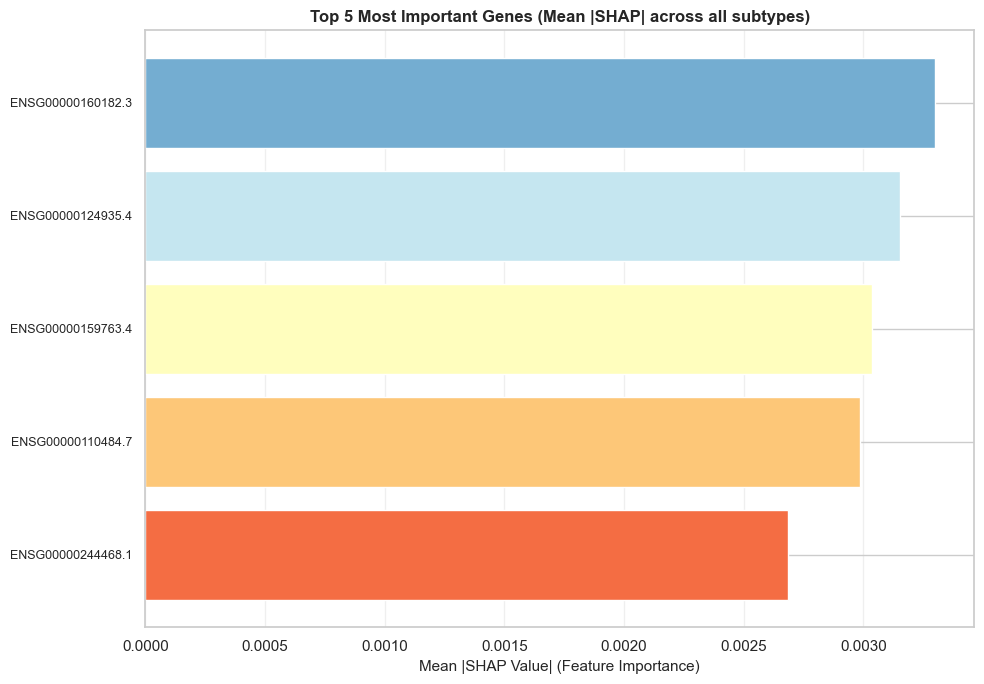

✅ Top 5 most important genes for subtype prediction:
    1. ENSG00000160182.3         SHAP=0.003298
    2. ENSG00000124935.4         SHAP=0.003153
    3. ENSG00000159763.4         SHAP=0.003038
    4. ENSG00000110484.7         SHAP=0.002985
    5. ENSG00000244468.1         SHAP=0.002687


In [32]:
# ── SHAP Summary Plot ──
# Shows which genes have the most impact across all samples and classes

shap_array = np.array(shap_values)  # (n_classes, n_samples, n_genes)

# Mean absolute SHAP across all classes and samples = overall gene importance
mean_abs_shap = np.mean(np.abs(shap_array), axis=(0, 1))  # (n_genes,)
top_n = min(20, len(mean_abs_shap))
top_idx       = np.argsort(mean_abs_shap)[::-1][:top_n]
top_genes     = [selected_genes[i] for i in top_idx]
top_shap_vals = mean_abs_shap[top_idx]

fig, ax = plt.subplots(figsize=(10, 7))
colors_shap = plt.cm.RdYlBu_r(np.linspace(0.2, 0.8, top_n))
bars = ax.barh(range(top_n)[::-1], top_shap_vals, color=colors_shap, edgecolor='white')
ax.set_yticks(range(top_n)[::-1])
ax.set_yticklabels([g[:20] for g in top_genes], fontsize=9)
ax.set_title(f'Top {top_n} Most Important Genes (Mean |SHAP| across all subtypes)',
             fontweight='bold', fontsize=12)
ax.set_xlabel('Mean |SHAP Value| (Feature Importance)', fontsize=11)
ax.grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'✅ Top {top_n} most important genes for subtype prediction:')
for i, (gene, val) in enumerate(zip(top_genes[:10], top_shap_vals[:10])):
    print(f'   {i+1:2d}. {gene:25s} SHAP={val:.6f}')

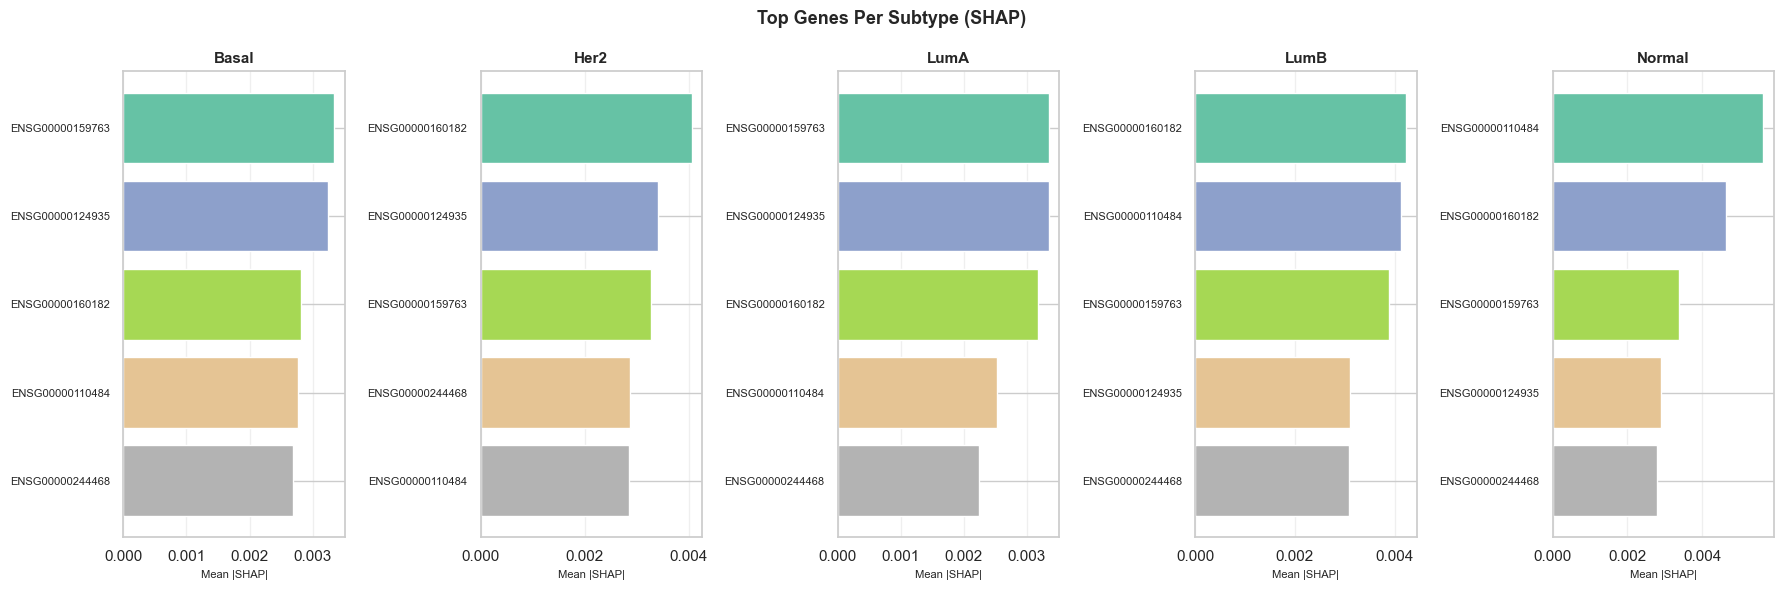

In [34]:
# --- SHAP Per-Class Gene Importance (Fixed) ---

fig, axes = plt.subplots(1, N_CLASSES, figsize=(18, 6), sharey=False)
fig.suptitle('Top Genes Per Subtype (SHAP)', fontsize=13, fontweight='bold')

for cls_idx, (cls_name, ax) in enumerate(zip(class_names, axes)):

    cls_shap = np.abs(shap_array[cls_idx])        # (n_samples, n_genes)
    cls_mean = np.mean(cls_shap, axis=0)          # (n_genes,)

    # ✅ Fix: dynamic top_per_class
    top_per_class = min(10, len(cls_mean))

    top_cls_idx = np.argsort(cls_mean)[::-1][:top_per_class]

    genes_cls = [selected_genes[j][:15] for j in top_cls_idx]
    vals_cls = cls_mean[top_cls_idx]

    colors_cls = plt.cm.Set2(np.linspace(0, 1, top_per_class))

    ax.barh(range(top_per_class)[::-1], vals_cls, color=colors_cls, edgecolor='white')
    ax.set_yticks(range(top_per_class)[::-1])
    ax.set_yticklabels(genes_cls, fontsize=8)

    ax.set_title(cls_name, fontsize=11, fontweight='bold')
    ax.set_xlabel('Mean |SHAP|', fontsize=8)
    ax.grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('shap_per_class.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 10: Gradio App

Interactive inference interface. Upload a gene expression profile → get:
- Predicted cancer subtype with confidence scores
- Survival risk score
- Top 10 contributing genes

Run this cell to launch the app. It opens a public URL you can share — or deploy directly to Hugging Face Spaces.

In [36]:
import gradio as gr
import json

# ── Save preprocessing artifacts alongside model ──
import pickle
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)
np.save('top_gene_indices.npy', top_gene_indices)
np.save('selected_genes.npy',   np.array(selected_genes))


def predict_sample(gene_expression_json: str) -> dict:
    """
    Run inference on a single patient's gene expression profile.

    Args:
        gene_expression_json: JSON string mapping gene_id → fpkm_value
                              Example: {"ENSG00000000003": 12.5, "ENSG00000000005": 0.0, ...}

    Returns:
        Dictionary with subtype probabilities, risk score, and top genes
    """
    try:
        # Parse input
        expr_dict = json.loads(gene_expression_json)

        # Build full gene vector (fill missing with 0)
        all_gene_ids = [c for c in df_merged.columns if c.startswith('ENSG')]
        full_vector  = np.array([expr_dict.get(g, 0.0) for g in all_gene_ids], dtype=np.float32)

        # Preprocessing pipeline
        log_vector      = np.log2(full_vector + 1)
        filtered_vector = log_vector[top_gene_indices]           # Variance filter
        scaled_vector   = scaler.transform([filtered_vector])    # StandardScaler

        # Inference
        model.eval()
        x_tensor = torch.tensor(scaled_vector, dtype=torch.float32).to(DEVICE)

        with torch.no_grad():
            logits, risk = model(x_tensor)
            probs        = torch.softmax(logits, dim=1).cpu().numpy()[0]
            risk_score   = risk.cpu().item()

        # Top predicted subtype
        pred_class = np.argmax(probs)
        pred_label = class_names[pred_class]
        confidence = float(probs[pred_class])

        # SHAP for this sample (top 10 genes)
        try:
            sample_shap  = explainer.shap_values(x_tensor)
            shap_for_pred = np.abs(np.array(sample_shap)[pred_class][0])
            top10_idx    = np.argsort(shap_for_pred)[::-1][:10]
            top10_genes  = {selected_genes[j]: float(shap_for_pred[j]) for j in top10_idx}
        except Exception:
            top10_genes  = {'SHAP_unavailable': 0.0}

        return {
            'predicted_subtype':   pred_label,
            'confidence':          f'{confidence:.1%}',
            'subtype_probabilities': {
                name: f'{float(p):.1%}'
                for name, p in zip(class_names, probs)
            },
            'survival_risk_score':   f'{risk_score:.4f} (0=low risk, 1=high risk)',
            'risk_level':            'HIGH' if risk_score > 0.5 else 'LOW',
            'top_contributing_genes': top10_genes
        }

    except Exception as e:
        return {'error': str(e)}


def demo_predict(use_demo_sample):
    """Wrapper for Gradio — uses a real test sample as demo."""
    # Use first test sample as demo
    demo_expr = {}
    all_gene_ids = [c for c in df_merged.columns if c.startswith('ENSG')]
    # Reverse the preprocessing to get approx original FPKM
    raw_sample = df_merged.iloc[0][gene_cols].values
    for gene_id, val in zip(all_gene_ids, raw_sample):
        demo_expr[gene_id] = float(val)

    result = predict_sample(json.dumps(demo_expr))

    output_lines = [
        f"🧬 ONCOPROFILO — BREAST CANCER MOLECULAR PROFILING",
        f"{'='*50}",
        f"",
        f"📌 PREDICTED SUBTYPE:  {result.get('predicted_subtype', 'N/A')}",
        f"   Confidence:         {result.get('confidence', 'N/A')}",
        f"",
        f"📊 SUBTYPE PROBABILITIES:",
    ]

    probs_dict = result.get('subtype_probabilities', {})
    for subtype, prob in probs_dict.items():
        bar_len = int(float(prob.strip('%')) / 5)
        output_lines.append(f"   {subtype:<12} {prob:>6}  {'█' * bar_len}")

    output_lines += [
        f"",
        f"⚠️  SURVIVAL RISK:",
        f"   Score: {result.get('survival_risk_score', 'N/A')}",
        f"   Level: {result.get('risk_level', 'N/A')}",
        f"",
        f"🔬 TOP CONTRIBUTING GENES (SHAP):",
    ]

    for gene, val in list(result.get('top_contributing_genes', {}).items())[:10]:
        output_lines.append(f"   {gene[:20]:<22} {val:.6f}")

    output_lines += [
        f"",
        f"{'='*50}",
        f"Model: OncoProfilo | Dataset: TCGA-BRCA",
        f"Author: Flowgenix AI"
    ]

    return '\n'.join(output_lines)


# ── Build Gradio Interface ──
with gr.Blocks(
    title='OncoProfilo',
    theme=gr.themes.Soft(primary_hue='blue')
) as demo:

    gr.Markdown("""
    # 🧬 OncoProfilo
    ## Breast Cancer Molecular Subtype Classification & Survival Risk Prediction
    **Model:** Multi-task MLP | **Data:** TCGA-BRCA RNA-seq | **Author:** Flowgenix AI

    Predict PAM50 molecular subtype (LumA / LumB / HER2 / Basal / Normal) and survival
    risk from a tumor's RNA-seq gene expression profile.
    """)

    with gr.Tab('📊 Demo Prediction'):
        gr.Markdown('Click the button to run a prediction on a real TCGA-BRCA test sample.')
        demo_btn = gr.Button('▶ Run Demo Prediction', variant='primary', size='lg')
        demo_out = gr.Textbox(label='Prediction Output', lines=30, max_lines=40)
        demo_btn.click(fn=demo_predict, inputs=[demo_btn], outputs=demo_out)

    with gr.Tab('🔬 Custom Input (JSON)'):
        gr.Markdown("""
        Paste a gene expression profile as JSON.
        Format: `{"ENSG00000000003": 12.5, "ENSG00000000005": 0.0, ...}`
        """)
        json_input = gr.Textbox(
            label='Gene Expression (JSON)',
            placeholder='{"ENSG00000000003": 12.5, "ENSG00000000005": 0.0}',
            lines=5
        )
        json_btn = gr.Button('▶ Predict', variant='primary')
        json_out = gr.JSON(label='Prediction Results')
        json_btn.click(fn=predict_sample, inputs=json_input, outputs=json_out)

    with gr.Tab('ℹ️ About'):
        gr.Markdown(f"""
        ## Model Details
        - **Architecture:** Multi-task MLP (shared encoder + 2 task heads)
        - **Classification task:** 5-class PAM50 subtype prediction (CrossEntropyLoss)
        - **Survival task:** Cox Proportional Hazards risk score
        - **Input:** Top {N_GENES} most variable genes (log2 normalized FPKM)
        - **Explainability:** SHAP DeepExplainer gene importance

        ## Subtypes
        | Subtype | Description | Prognosis |
        |---------|-------------|----------|
        | LumA    | Luminal A — hormone receptor +ve, slow growing | Best |
        | LumB    | Luminal B — hormone receptor +ve, faster growing | Good |
        | Her2    | HER2-enriched — HER2 gene amplified | Moderate |
        | Basal   | Basal-like / Triple negative | Worst |
        | Normal  | Normal-like | Variable |

        ## Dataset
        TCGA-BRCA — The Cancer Genome Atlas Breast Cancer cohort
        ~1,100 patients | RNA-seq FPKM-UQ | Clinical outcomes
        """)

print('🚀 Launching OncoProfilo Gradio App...')
demo.launch(share=False, debug=False)  # share=False for VS Code; set True to get a public URL

🚀 Launching OncoProfilo Gradio App...
* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


---
## ✅ Project Complete — What You Built

| Component | Description |
|-----------|-------------|
| Data pipeline | TCGA-BRCA RNA-seq downloaded via GDC API — no local storage |
| Preprocessing | Log2 normalization → variance filtering → StandardScaler |
| Model | Multi-task MLP: shared encoder + classification head + Cox survival head |
| Classification | 5-class PAM50 subtype prediction (Accuracy, F1, AUC) |
| Survival | Cox PH loss → risk scores → C-index + Kaplan-Meier curves |
| Explainability | SHAP gene importance — global + per-subtype + per-sample |
| App | Interactive Gradio interface — deployable to Hugging Face Spaces |

### Next Step → OncoProfilo v2 (Multi-Omics)
Add a second data modality — **DNA methylation** or **copy number variation** from TCGA-BRCA — and fuse them with gene expression using an attention-based fusion architecture. That's your Option 3 project.

---
*Built by Muhammed Panchla | Flowgenix AI*